Best Parameters: window                90
regime              High
sharpe          0.741162
abs_return    307694.875
Name: 2, dtype: object

--- Strategy Metrics ---
Sharpe: 1.6440
Absolute Return: 307694.875
Max Drawdown: -72571.359375
Max Drawdown %: -21.4401
Win Rate: 0.5726
Trade Count: 4636


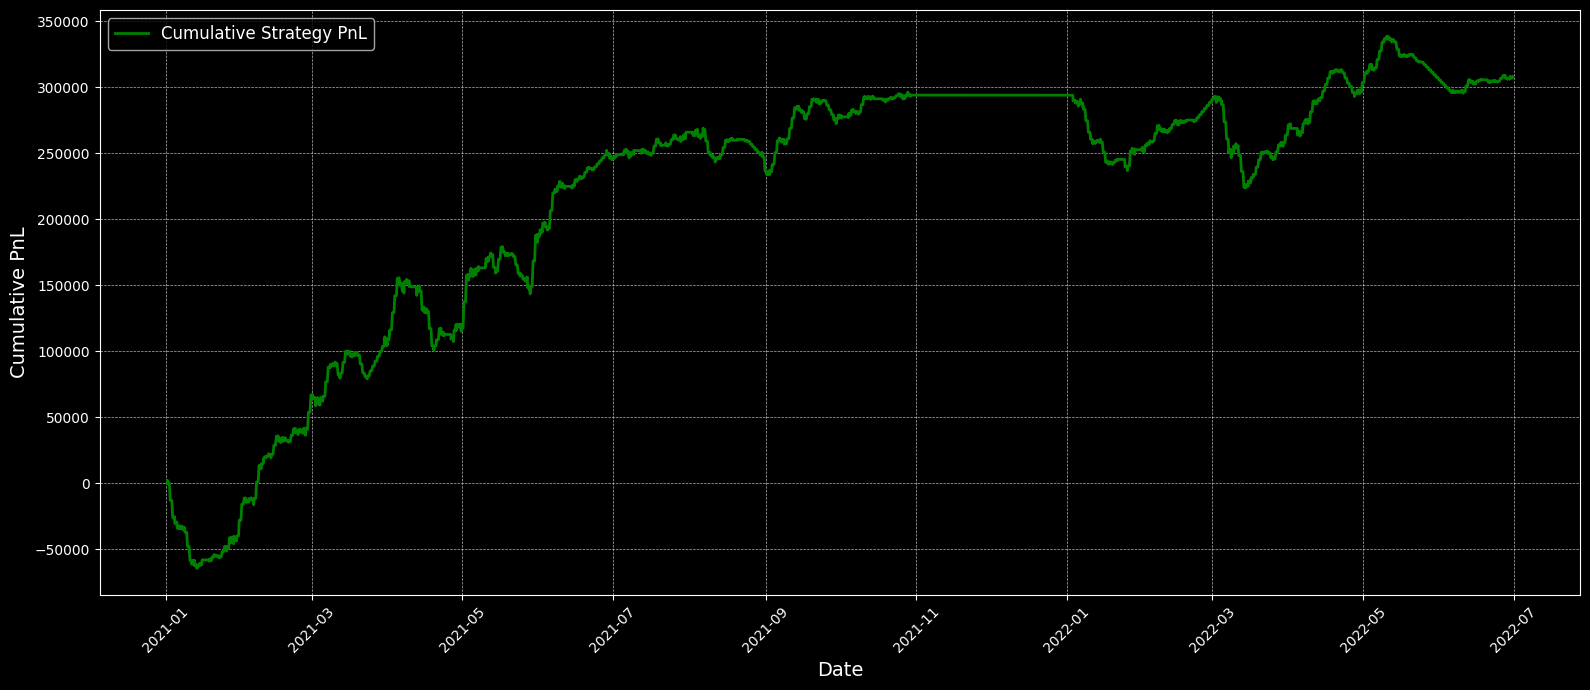

In [22]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
import os

# --- Data Loading ---
def load_data():
    df = pd.read_parquet(
        '/Users/santhoshvenkatesan/Repo/truebeacon/data',
        columns=['nifty', 'banknifty', 'tte']
    )
    df = df.astype('float32')
    df.index = pd.to_datetime(df.index)
    return df.ffill()

# --- Cointegration ---
def calculate_cointegration(df):
    df['coint_spread'] = 38.8518 * df['nifty'] - 39.1766 * df['banknifty']
    return df

# --- Feature Engineering ---
def calculate_features(df, windows):
    for window in windows:
        mean = df['coint_spread'].rolling(window, min_periods=1).mean()
        std = df['coint_spread'].rolling(window, min_periods=1).std().replace(0, np.nan).ffill().bfill()
        df[f'zscore_{window}'] = ((df['coint_spread'] - mean) / std).fillna(0).astype('float32')
        del mean, std
        gc.collect()
    return df

# --- Grid Search ---
def optimized_grid(df, windows):
    params = {
        'Low': (1.2, 0.4),
        'Medium': (1.5, 0.6),
        'High': (2.0, 0.8)
    }
    results = []
    spread = df['coint_spread'].values.astype('float32')
    tte = df['tte'].values.astype('float32')
    hour_mask = (df.index.hour.values >= 9) & (df.index.hour.values <= 15)
    for window in windows:
        zscore = df[f'zscore_{window}'].values.astype('float32')
        vol = df['coint_spread'].rolling(window).std().values.astype('float32')
        for regime, (entry, exit) in params.items():
            position = np.zeros(len(df), dtype='int8')
            current_pos = 0
            for i in range(window, len(df)):
                if not hour_mask[i]:
                    continue
                current_vol = vol[i]
                if regime == 'High' and current_vol < np.quantile(vol, 0.66):
                    continue
                elif regime == 'Medium' and not (np.quantile(vol, 0.33) < current_vol < np.quantile(vol, 0.66)):
                    continue
                elif regime == 'Low' and current_vol > np.quantile(vol, 0.33):
                    continue
                z = zscore[i]
                if current_pos == 0:
                    if z > entry:
                        current_pos = -1
                    elif z < -entry:
                        current_pos = 1
                elif current_pos == 1 and z >= exit:
                    current_pos = 0
                elif current_pos == -1 and z <= -exit:
                    current_pos = 0
                position[i] = current_pos
            pnl = position * (spread * (tte ** 0.7))
            sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252) if pnl.std() > 0 else 0
            results.append({
                'window': window,
                'regime': regime,
                'sharpe': sharpe,
                'abs_return': pnl.sum()
            })
            del pnl
            gc.collect()
    return pd.DataFrame(results)

# --- Apply Best Strategy ---
def apply_strategy(df, window, regime, entry, exit):
    spread = df['coint_spread'].values.astype('float32')
    tte = df['tte'].values.astype('float32')
    zscore = df[f'zscore_{window}'].values.astype('float32')
    vol = df['coint_spread'].rolling(window).std().values.astype('float32')
    hour_mask = (df.index.hour.values >= 9) & (df.index.hour.values <= 15)
    position = np.zeros(len(df), dtype='int8')
    current_pos = 0
    q33, q66 = np.quantile(vol, 0.33), np.quantile(vol, 0.66)
    for i in range(window, len(df)):
        if not hour_mask[i]:
            continue
        current_vol = vol[i]
        if regime == 'High' and current_vol < q66:
            continue
        elif regime == 'Medium' and not (q33 < current_vol < q66):
            continue
        elif regime == 'Low' and current_vol > q33:
            continue
        z = zscore[i]
        if current_pos == 0:
            if z > entry:
                current_pos = -1
            elif z < -entry:
                current_pos = 1
        elif current_pos == 1 and z >= exit:
            current_pos = 0
        elif current_pos == -1 and z <= -exit:
            current_pos = 0
        position[i] = current_pos
    df['position'] = position
    df['trade_pnl'] = df['position'] * (df['coint_spread'] * (df['tte'] ** 0.7))
    df['cum_pnl'] = df['trade_pnl'].cumsum()
    return df

# --- Metrics Calculation ---
def calculate_metrics(df):
    pnl = df['trade_pnl']
    returns = pnl.replace(0, np.nan).dropna()
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() > 0 else np.nan
    abs_return = returns.sum()
    cum_pnl = df['cum_pnl']
    roll_max = cum_pnl.cummax()
    drawdown = (cum_pnl - roll_max)
    max_drawdown = drawdown.min()
    max_drawdown_pct = (max_drawdown / roll_max.max()) * 100 if roll_max.max() != 0 else np.nan
    wins = (returns > 0).sum()
    losses = (returns < 0).sum()
    win_rate = wins / (wins + losses) if (wins + losses) > 0 else np.nan
    trades = (df['position'].diff().abs() > 0).sum()
    return {
        'Sharpe': sharpe,
        'Absolute Return': abs_return,
        'Max Drawdown': max_drawdown,
        'Max Drawdown %': max_drawdown_pct,
        'Win Rate': win_rate,
        'Trade Count': trades
    }

# --- Main Execution ---
windows = [90, 120, 150, 180]
df = load_data()
df = calculate_cointegration(df)
df = calculate_features(df, windows=windows)
cache_path = 'light_results.pkl'
if not os.path.exists(cache_path):
    results = optimized_grid(df, windows=windows)
    results.to_pickle(cache_path)
else:
    results = pd.read_pickle(cache_path)
best = results.sort_values('sharpe', ascending=False).iloc[0]
print(f"Best Parameters: {best}")
df = apply_strategy(
    df,
    int(best['window']),
    best['regime'],
    float({'Low':1.2, 'Medium':1.5, 'High':2.0}[best['regime']]),  # entry
    float({'Low':0.4, 'Medium':0.6, 'High':0.8}[best['regime']])   # exit
)
metrics = calculate_metrics(df)
print("\n--- Strategy Metrics ---")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

# --- Visualizations ---
plt.style.use('dark_background') 
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(df.index, df['cum_pnl'], label='Cumulative Strategy PnL', color='green', linewidth=2)
#ax.set_title('Cumulative (Absolute) Strategy PnL', fontsize=18, fontweight='bold')
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Cumulative PnL', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()